# Notebook 81 — final alpha trace and notebook-only patch

This notebook traces MATLAB's final `alpha` relative to forward `X_plus[:,1]`, smoothing, and `Fascicle.A`, then applies a notebook-only Python patch that mirrors that exact mathematical path without changing the raw module.

In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Markdown, Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_final_alpha_trace_patch.py'
OUT = ROOT / 'results' / 'notebook81_final_alpha_trace_patch'
print(f'Project root: {ROOT}')
print(f'Script: {SCRIPT}')
print(f'Output directory: {OUT}')

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_final_alpha_trace_patch.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook81_final_alpha_trace_patch


In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
completed

# Notebook 81 — final alpha trace and notebook-only patch

Aligned 2666 MATLAB/Python samples with Python offset 1.

This notebook traces where MATLAB's final `alpha` comes from relative to forward `X_plus[:,1]`, smoothing, and `Fascicle.A`, then applies a notebook-only Python patch that mirrors the same mathematical path without editing the production module.

## MATLAB trace result

- MATLAB's saved `Fascicle.alpha` is exactly the scalar RTS-style smoother result on the angle channel.
- Using MATLAB's saved forward `X_plus[:,1]`, predicted `X_minus[:,1]`, and saved `Fascicle.A`, the recursive trace

  `alpha_smooth[t] = X_plus[t,1] + A[t] * (alpha_smooth[t+1] - X_minus[t+1,1])`

  reproduces saved MATLAB `alpha` with RMSE 0.000000 deg exactly.
- By contrast, MATLAB forward `X_plus[:,1]` differs from MATLAB final `alpha` by RMSE 0.2779 deg.

## Notebook-only Python patch

- The notebook patch does not guess or brute-force MATLAB outputs. It recomputes the final Python alpha from Pytho

CompletedProcess(args=['/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_final_alpha_trace_patch.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook81_summary.md').read_text()))

# Notebook 81 — final alpha trace and notebook-only patch

Aligned 2666 MATLAB/Python samples with Python offset 1.

This notebook traces where MATLAB's final `alpha` comes from relative to forward `X_plus[:,1]`, smoothing, and `Fascicle.A`, then applies a notebook-only Python patch that mirrors the same mathematical path without editing the production module.

## MATLAB trace result

- MATLAB's saved `Fascicle.alpha` is exactly the scalar RTS-style smoother result on the angle channel.
- Using MATLAB's saved forward `X_plus[:,1]`, predicted `X_minus[:,1]`, and saved `Fascicle.A`, the recursive trace

  `alpha_smooth[t] = X_plus[t,1] + A[t] * (alpha_smooth[t+1] - X_minus[t+1,1])`

  reproduces saved MATLAB `alpha` with RMSE 0.000000 deg exactly.
- By contrast, MATLAB forward `X_plus[:,1]` differs from MATLAB final `alpha` by RMSE 0.2779 deg.

## Notebook-only Python patch

- The notebook patch does not guess or brute-force MATLAB outputs. It recomputes the final Python alpha from Python's own forward `X_plus[:,1]`, `X_minus[:,1]`, and scalar smoother ratio `A = P_plus / P_minus(next)` on the angle channel, using the same recursion as MATLAB.
- That notebook-only patch is a strict no-op on the current Python run: patched alpha differs from the saved smoothed Python alpha by RMSE 0.000000 deg, and patched FL differs from the saved Python FL by RMSE 0.000000 mm.

## Final comparison

- Final alpha parity does not move under the notebook patch: MATLAB final-alpha RMSE stays 1.1661 deg before the patch and 1.1661 deg after it.
- Deep-end geometry does not move either: `fas_x_end` x_deep RMSE stays 25.80 px before the patch and 25.80 px after it.
- Final FL parity also stays unchanged: FL RMSE stays 2.0117 mm before the patch and 2.0117 mm after it.

## Interpretation

- This is the outcome we wanted for safety: the exact MATLAB alpha path is already what Python is numerically doing on the saved run.
- So there is no evidence of a hidden mathematical anomaly in the current backward alpha smoother itself.
- The remaining gap is upstream of this patch, mainly in the forward angle/state inputs that the smoother receives.
- If we patch production code later, it should be for clarity and contract correctness — for example preserving forward `X_plus` as forward state and exposing smoothed state separately — not because this notebook found a missing alpha recursion.

- Alpha trace metrics: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook81_final_alpha_trace_patch/alpha_trace_metrics.csv`
- Patch comparison metrics: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook81_final_alpha_trace_patch/patched_vs_current_vs_matlab.csv`
- Patch delta metrics: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook81_final_alpha_trace_patch/patch_delta_vs_current.csv`
- Alpha trace plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook81_final_alpha_trace_patch/alpha_trace_examples.png`
- Patch summary plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook81_final_alpha_trace_patch/patch_effect_summary.png`

## MATLAB source trace

- The exact smoother loop appears in `UltraTimTrack.m` around lines 2287–2301, where `xsmooth(m) = xcorr(m) + A*(xsmooth(m) - xpred(m))`, then `alpha_smooth = xsmooth(2)` is written back to `handles.Region(i).Fascicle(j).alpha{frame_no}`.


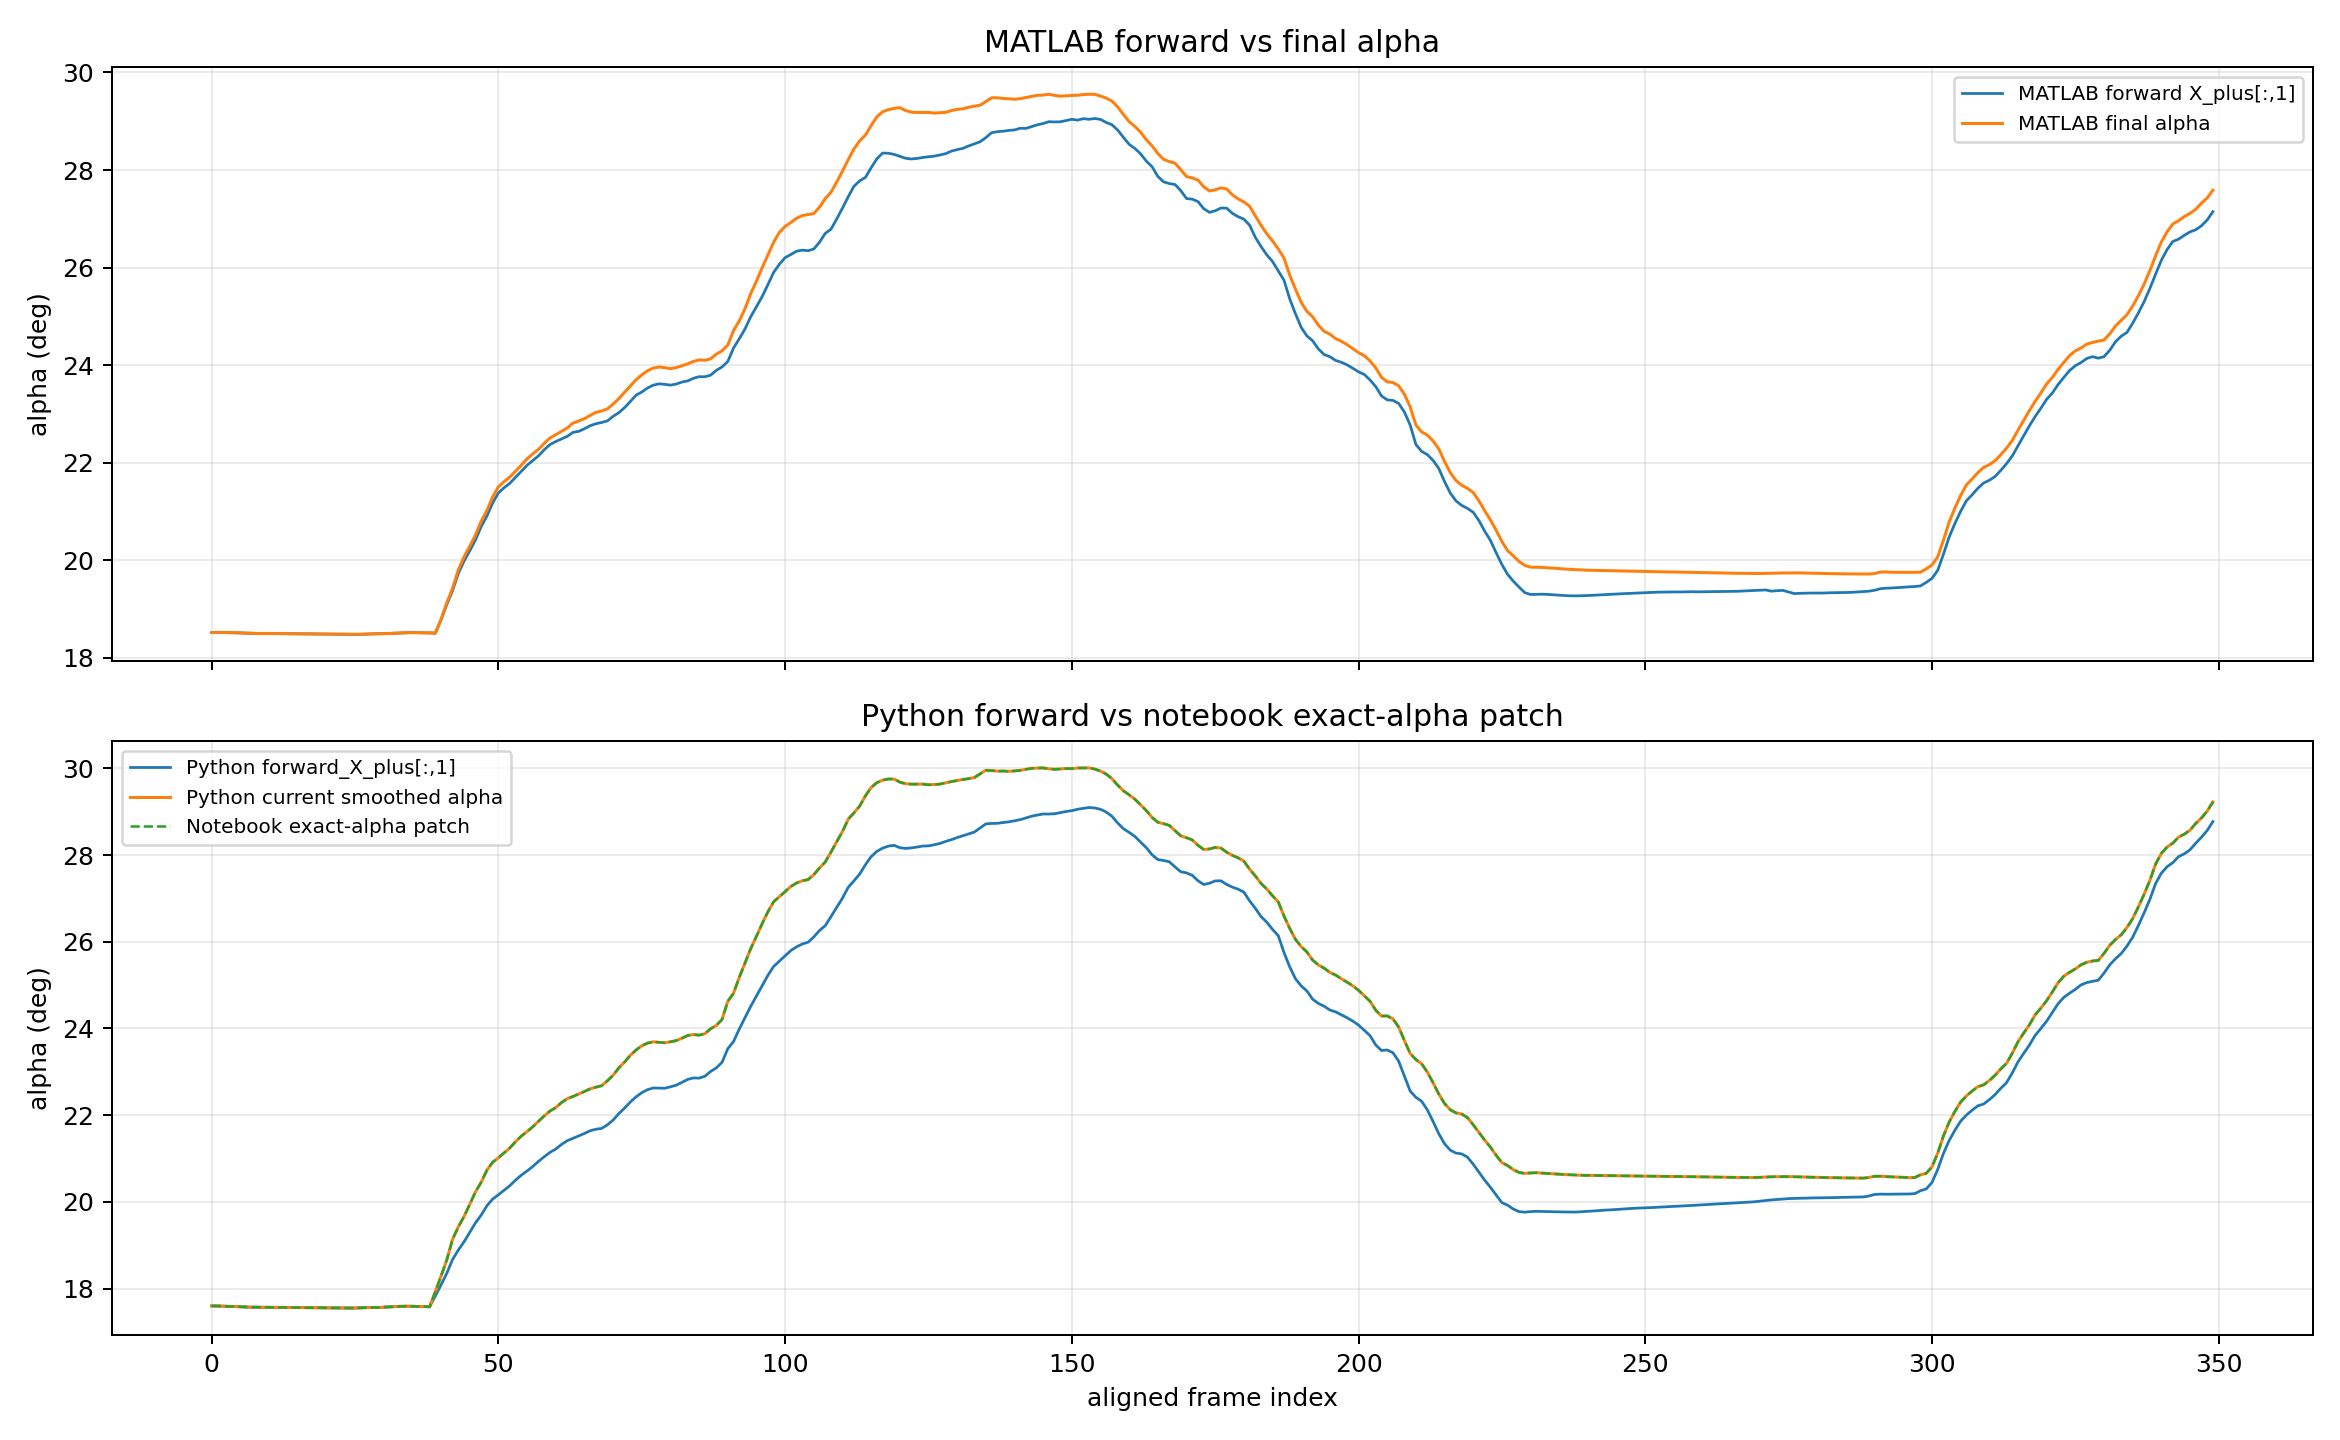

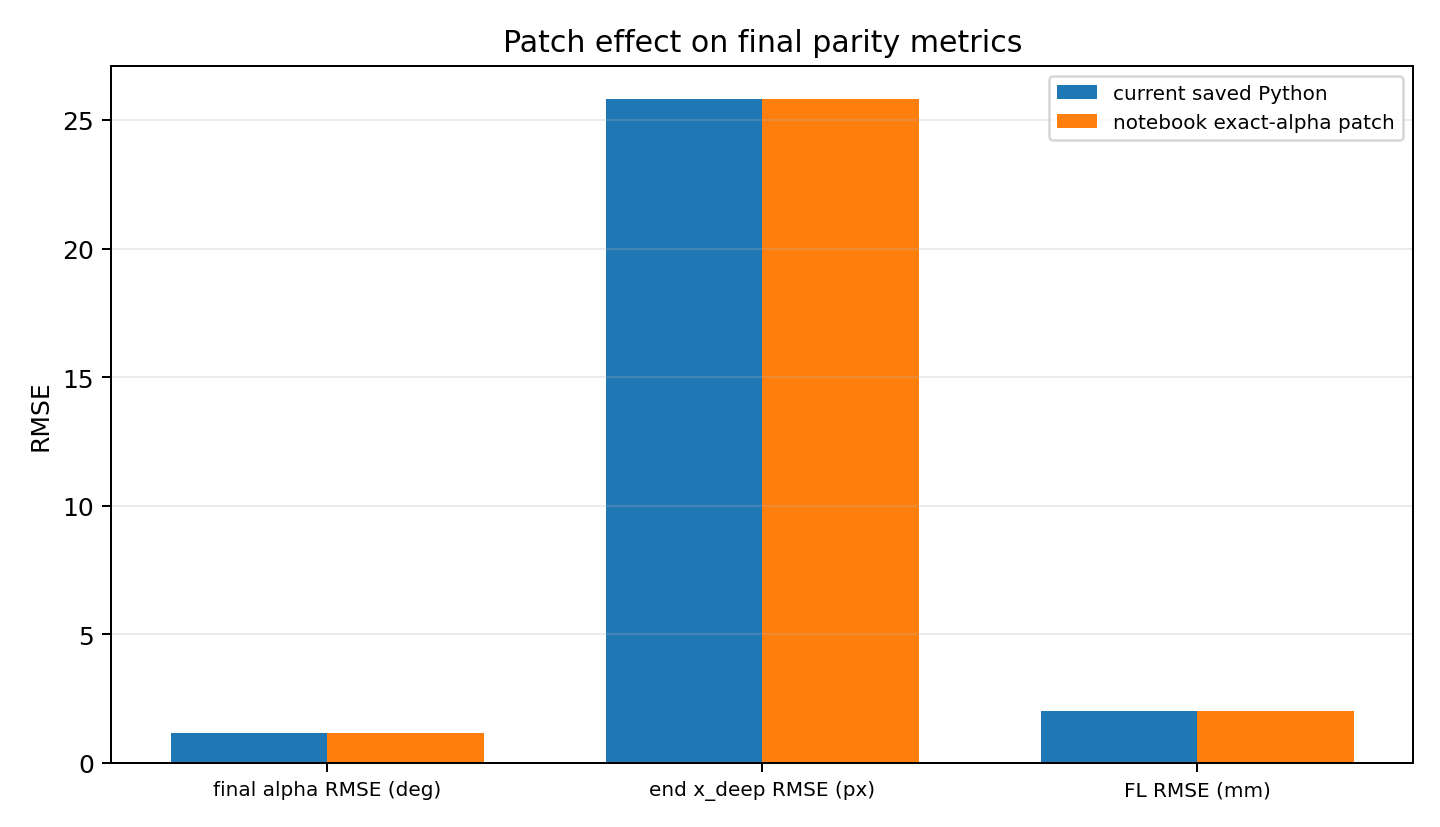

In [4]:
display(Image(filename=str(OUT / 'alpha_trace_examples.png')))
display(Image(filename=str(OUT / 'patch_effect_summary.png')))